# Test 2: Quadruple-Well KSWGD and DMPS

This notebook keeps the original quadruple-well data generation, parameter values, DMPS update, and KSWGD update. Shared Python modules hold the repeated implementation details.

In [1]:
from dataclasses import replace
import time

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from plotting_utils import setup_plot_style, ensure_dir
setup_plot_style(scale=1.5)
np.random.seed(42)

from systems import (
    QuadrupleWellConfig, FourWellPotential,
    generate_quadruple_langevin_trajectory,
    init_quadruple_particles_uniform_outside,
)
from dmps import fit_diffusion_map_dmps_2d, run_diffusion_map_dmps_2d
from kswgd import train_sdmd_solver, sdmd_kernel_spectrum_2d, run_kernel_spectrum_transport_2d
from baseline import (
    mmd_rbf, sliced_wasserstein, particle_well_coverage,
    compute_kl_divergence_kde,
)
from experiment_plots import (
    plot_quad_pair_snapshots, plot_quad_heatmaps, plot_quad_movement_rate,
    plot_quad_well_density_evolution, plot_quad_kl_divergence,
)

cfg = replace(
    QuadrupleWellConfig(),
    n_target=10000, n_particles=3000, n_iter=3000,
    step_size=0.05, dt=0.01, substeps=10, burnin=1000, seed=42,
)
potential = FourWellPotential(cfg.temperature, a=cfg.a, b=cfg.b, coupling=cfg.coupling)
WELL_CENTERS = FourWellPotential.centers
WELL_RADIUS = 0.4
ALPHA_REPULSIVE = 0.5
DM_SPECTRAL_MODES = 1000
RECORD_INTERVAL = 100
SNAPSHOT_STEPS = [0, 1000, 3000]
WELL_DENSITY_STEPS = [0, 100, 300, 500, 1000, 1500, 2000, 2500, 3000]
KL_STEPS = list(range(0, cfg.n_iter + 1, 100))
ALL_SNAPSHOT_STEPS = sorted(set(SNAPSHOT_STEPS + WELL_DENSITY_STEPS + KL_STEPS))
ensure_dir('figures/quadruple_well')
print(cfg)
print(f'alpha_repulsive={ALPHA_REPULSIVE}, well_radius={WELL_RADIUS}, DM spectral modes={DM_SPECTRAL_MODES}')

QuadrupleWellConfig(n_target=10000, n_particles=3000, n_iter=3000, step_size=0.05, dt=0.01, burnin=1000, substeps=10, temperature=1.0, a=1.0, b=1.0, coupling=0.0, seed=42, bounds=(-2.0, 2.0))
alpha_repulsive=0.5, well_radius=0.4, DM spectral modes=1000


In [2]:
start = time.time()
X_tar, X_next, trajectory = generate_quadruple_langevin_trajectory(cfg, potential, return_trajectory=True)
X_init = init_quadruple_particles_uniform_outside(cfg, radius=WELL_RADIUS, seed=cfg.seed)
print(f'X_tar shape: {X_tar.shape}; X_next shape: {X_next.shape}; trajectory shape: {trajectory.shape}')
print(f'Initial outside-well particles: {X_init.shape[0]} from {cfg.n_particles} uniform candidates')

print('\nFitting the original DMPS diffusion-map spectrum...')
dmps_model = fit_diffusion_map_dmps_2d(X_tar, dt=cfg.dt, max_modes=DM_SPECTRAL_MODES)
print(f'DMPS epsilon={dmps_model.epsilon:.6f}; modes available={len(dmps_model.eigenvalues)}')

print('\nRunning DMPS with the original repulsive-force update...')
dmps = run_diffusion_map_dmps_2d(
    dmps_model, X_init, n_iter=cfg.n_iter, step_size=cfg.step_size,
    alpha_repulsive=ALPHA_REPULSIVE, snapshot_steps=ALL_SNAPSHOT_STEPS,
    record_interval=RECORD_INTERVAL, potential=potential, well_centers=WELL_CENTERS,
    well_radius=WELL_RADIUS, progress=True,
)

print('\nTraining the original neural dictionary spectrum for KSWGD...')
solver = train_sdmd_solver(
    X_tar, X_next, input_size=2, layer_sizes=[20], n_psi_train=17,
    target_dim=2, delta_t=cfg.dt, reg=0.1, epochs=6, batch_size=256,
    lr=1e-5, fnn_batch_size=32,
    checkpoint_file='quadruple_well_2d_example_ckpt001.torch',
    fnn_checkpoint_file='example_fnn001.torch',
    a_b_file='a_b_example_quadruple_well.jbl',
)
kswgd_model = sdmd_kernel_spectrum_2d(solver, X_tar, base_kernel=dmps_model, dt=cfg.dt, method='KSWGD')
print(f'KSWGD modes available={len(kswgd_model.eigenvalues)}')

print('\nRunning KSWGD with the original target-kernel SDMD update...')
kswgd = run_kernel_spectrum_transport_2d(
    kswgd_model, X_init, n_iter=cfg.n_iter, step_size=cfg.step_size,
    alpha_repulsive=ALPHA_REPULSIVE, snapshot_steps=ALL_SNAPSHOT_STEPS,
    record_interval=RECORD_INTERVAL, potential=potential, well_centers=WELL_CENTERS,
    well_radius=WELL_RADIUS, progress=True,
)

for name, res in {'DMPS': dmps, 'KSWGD': kswgd}.items():
    print(
        f"{name}: MMD={mmd_rbf(X_tar, res.final):.4f}, "
        f"SW={sliced_wasserstein(X_tar, res.final, seed=cfg.seed):.4f}, "
        f"particle well coverage={particle_well_coverage(res.final, WELL_CENTERS, WELL_RADIUS):.1f}%"
    )
print(f'Test 2 computation finished in {(time.time() - start) / 60:.2f} min')

CACHE_PATH = 'data/test_2_quadruple_well_core_cache.npz'
ensure_dir('data')
cache_steps = np.asarray(ALL_SNAPSHOT_STEPS, dtype=int)
np.savez_compressed(
    CACHE_PATH,
    X_tar=X_tar,
    X_next=X_next,
    X_init=X_init,
    cache_steps=cache_steps,
    dmps_snapshots=np.stack([dmps.snapshots[int(step)] for step in cache_steps], axis=0),
    kswgd_snapshots=np.stack([kswgd.snapshots[int(step)] for step in cache_steps], axis=0),
    dmps_metric_steps=dmps.metrics['steps'],
    dmps_well_coverage=dmps.metrics['well_coverage'],
    dmps_avg_potential=dmps.metrics['avg_potential'],
    dmps_movement_rate=dmps.metrics['movement_rate'],
    kswgd_metric_steps=kswgd.metrics['steps'],
    kswgd_well_coverage=kswgd.metrics['well_coverage'],
    kswgd_avg_potential=kswgd.metrics['avg_potential'],
    kswgd_movement_rate=kswgd.metrics['movement_rate'],
)
print(f'Saved core test2 cache: {CACHE_PATH}')

X_tar shape: (9999, 2); X_next shape: (9999, 2); trajectory shape: (10000, 2)
Initial outside-well particles: 2609 from 3000 uniform candidates

Fitting the original DMPS diffusion-map spectrum...


DMPS epsilon=0.020000; modes available=1000

Running DMPS with the original repulsive-force update...


DMPS: step 500/3000, mean step norm=1.296e-04


DMPS: step 1000/3000, mean step norm=6.272e-05


DMPS: step 1500/3000, mean step norm=4.547e-05


...

KSWGD: step 2000/3000, mean step norm=7.372e-05


KSWGD: step 2500/3000, mean step norm=7.077e-05


KSWGD: step 3000/3000, mean step norm=6.889e-05


DMPS: MMD=0.1999, SW=0.3554, particle well coverage=16.2%


KSWGD: MMD=0.1882, SW=0.3315, particle well coverage=66.0%
Test 2 computation finished in 7.80 min
Saved core test2 cache: data/test_2_quadruple_well_core_cache.npz


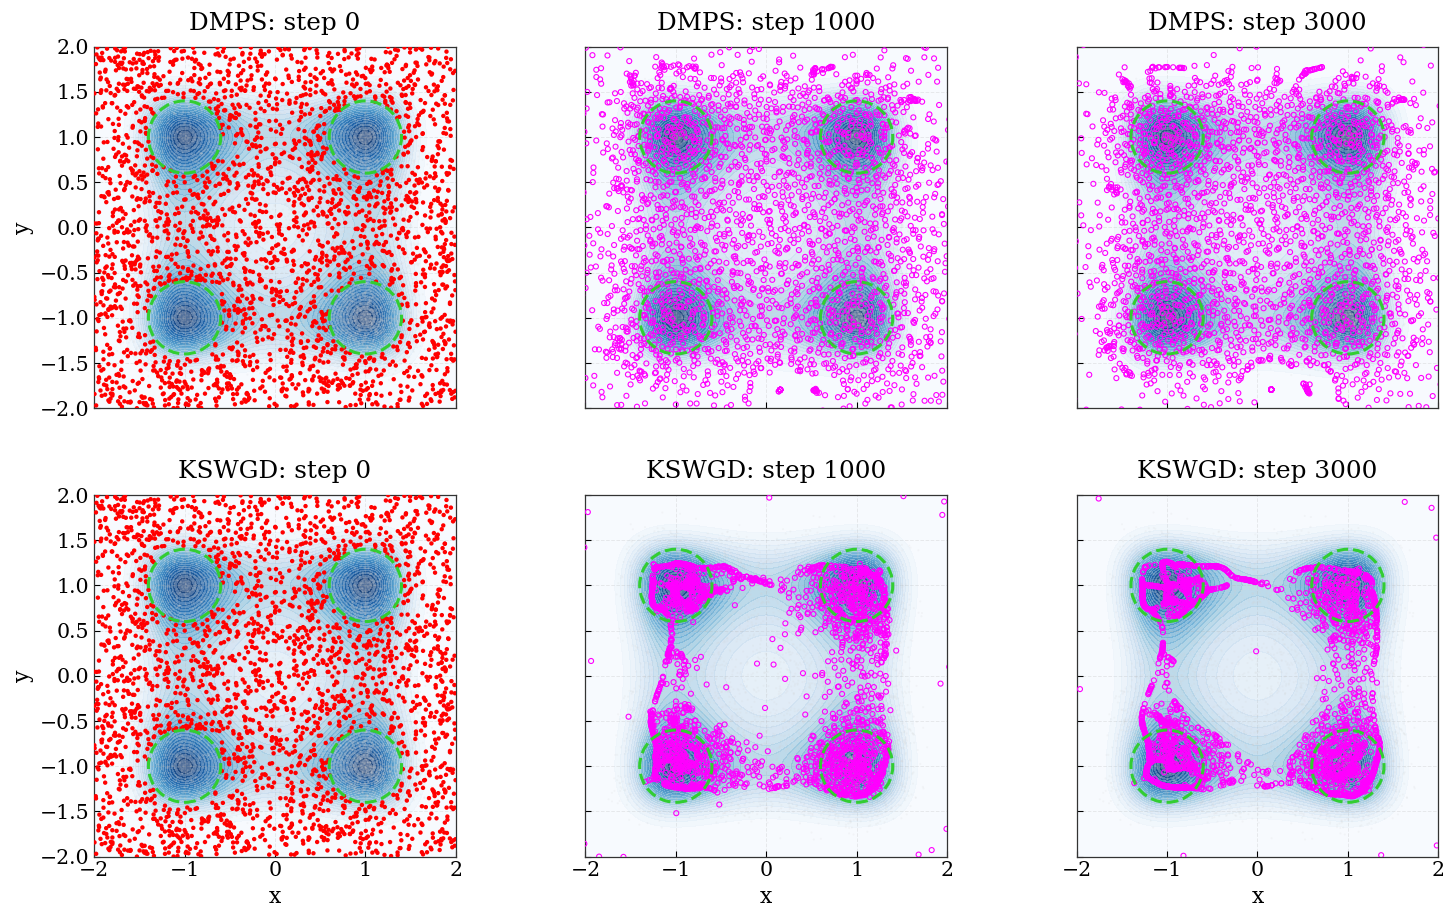

Caption: Quadruple-well particle positions at initialization, 1000 iterations, and 3000 iterations for DMPS and KSWGD.
Saved: figures/quadruple_well/test_2_quadruple_well_particle_snapshots.png and figures/quadruple_well/test_2_quadruple_well_particle_snapshots.pdf


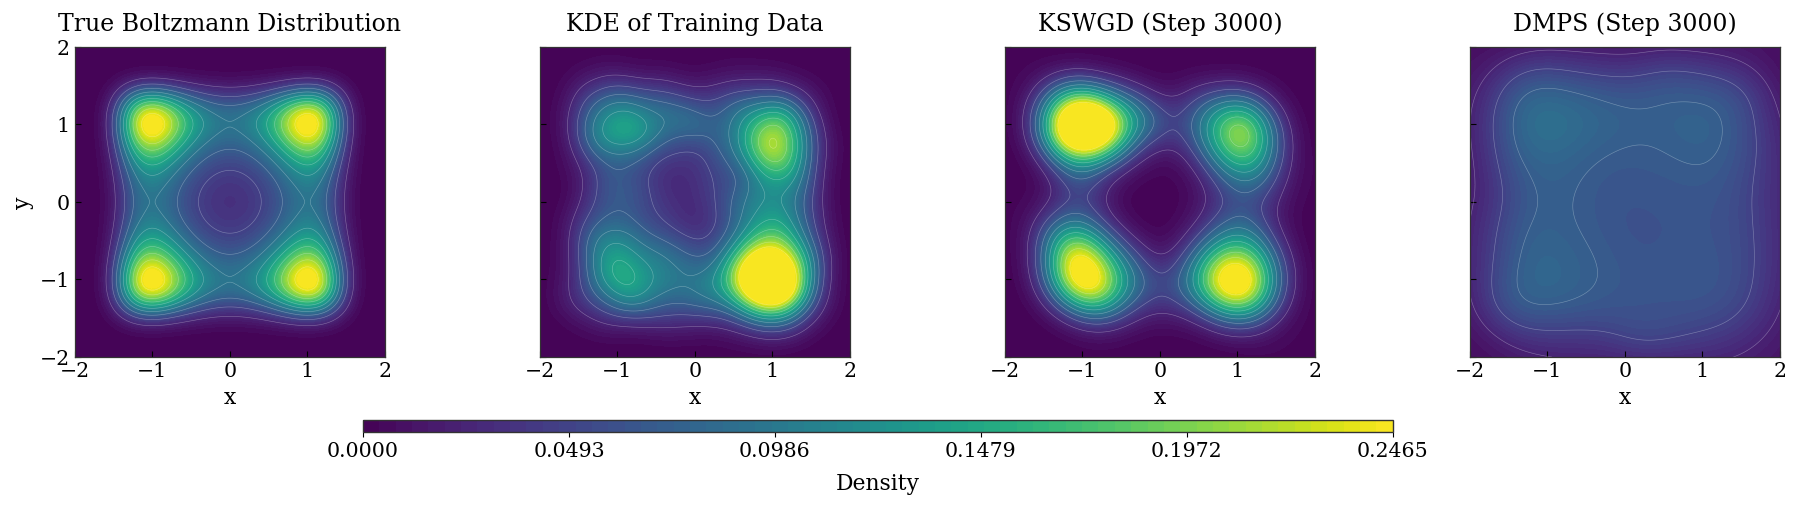

Caption: Density heatmap comparison for the quadruple-well Boltzmann law, training trajectory, KSWGD final particles, and DMPS final particles.
Saved: figures/quadruple_well/test_2_quadruple_well_density_heatmaps.png and figures/quadruple_well/test_2_quadruple_well_density_heatmaps.pdf


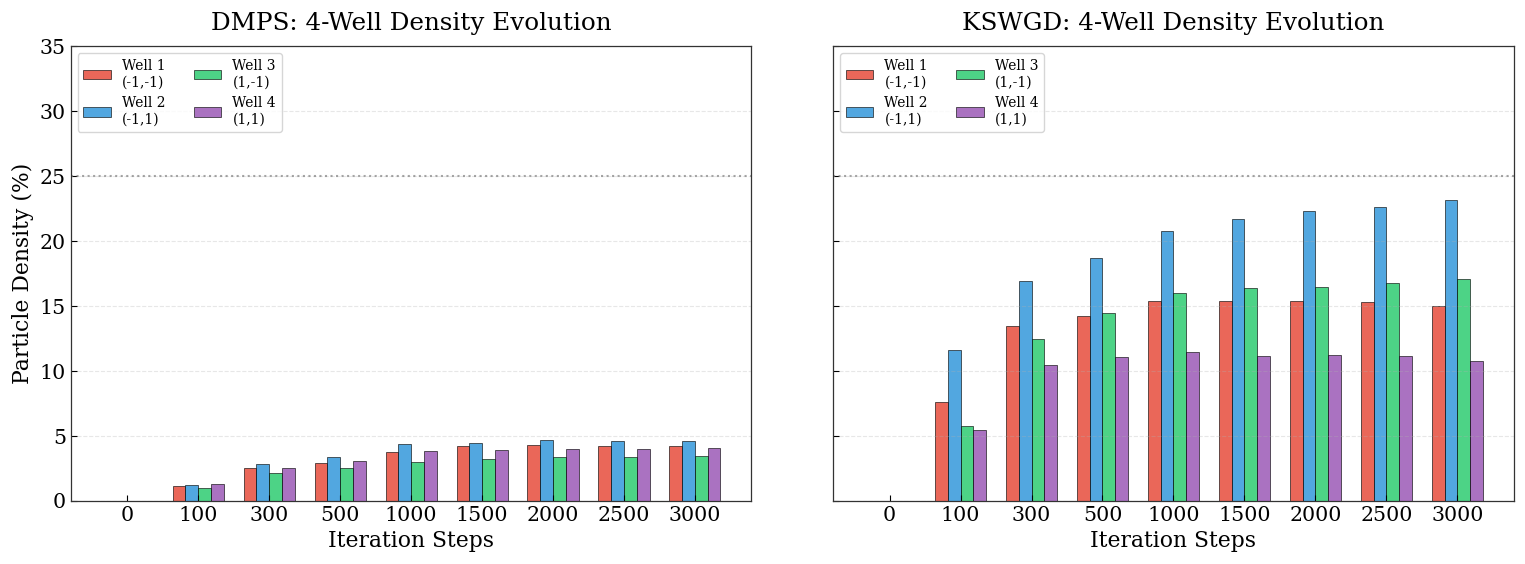

Caption: Percentage of particles in each of the four wells over iterations for DMPS and KSWGD.
Saved: figures/quadruple_well/test_2_quadruple_well_well_density_evolution.png and figures/quadruple_well/test_2_quadruple_well_well_density_evolution.pdf


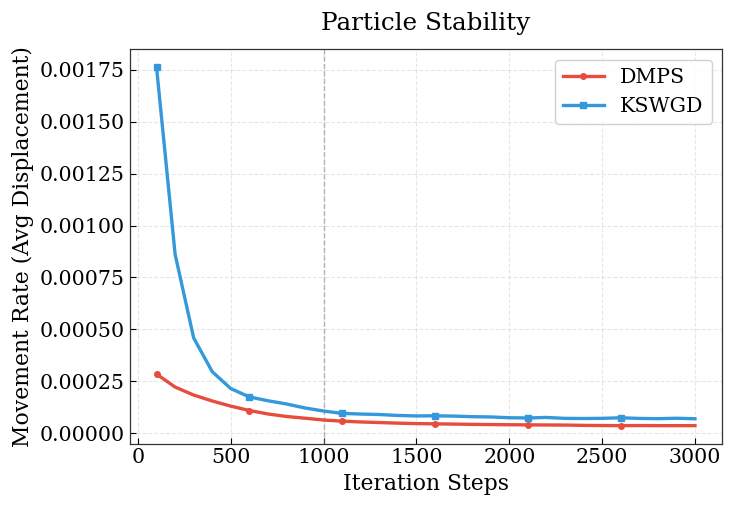

Caption: Mean particle displacement per recorded step for DMPS and KSWGD in the quadruple-well experiment.
Saved: figures/quadruple_well/test_2_quadruple_well_movement_rate.png and figures/quadruple_well/test_2_quadruple_well_movement_rate.pdf
Computing KL divergence curves...


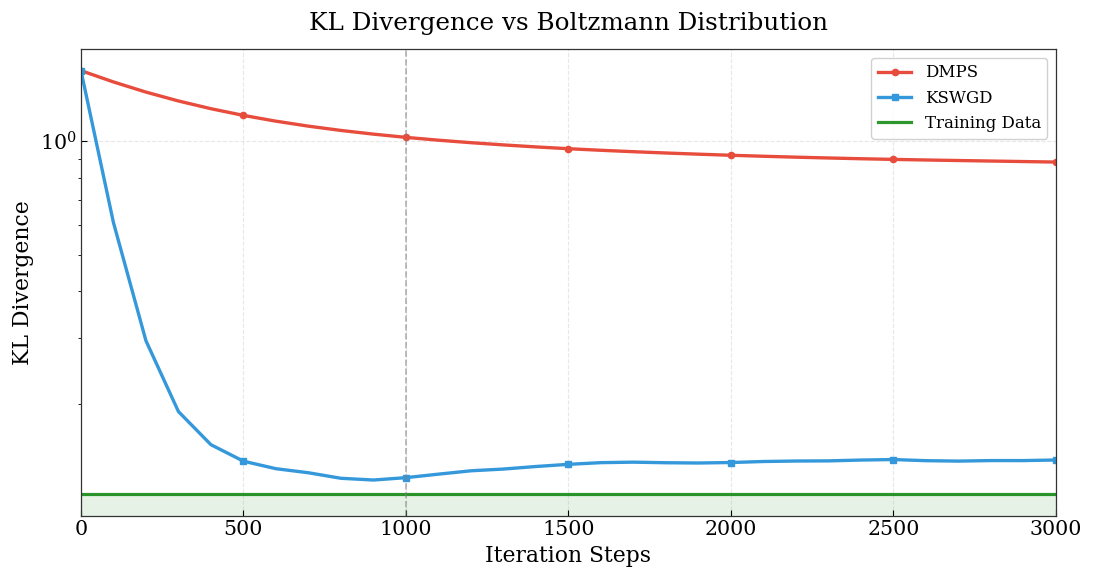

Caption: KL divergence from the true quadruple-well Boltzmann distribution over iterations for DMPS and KSWGD.
Saved: figures/quadruple_well/test_2_quadruple_well_kl_divergence.png and figures/quadruple_well/test_2_quadruple_well_kl_divergence.pdf
Training-data KL: 0.1151
DMPS: initial KL=1.5420, final KL=0.8809
KSWGD: initial KL=1.5420, final KL=0.1421


In [3]:
snapshot_view = {
    'DMPS': {step: dmps.snapshots[step] for step in SNAPSHOT_STEPS},
    'KSWGD': {step: kswgd.snapshots[step] for step in SNAPSHOT_STEPS},
}
plot_quad_pair_snapshots(
    snapshot_view, X_target=X_tar, potential=potential, bounds=cfg.bounds,
    centers=WELL_CENTERS, radius=WELL_RADIUS,
    stem='figures/quadruple_well/test_2_quadruple_well_particle_snapshots',
    caption='Quadruple-well particle positions at initialization, 1000 iterations, and 3000 iterations for DMPS and KSWGD.',
)
plot_quad_heatmaps(
    {
        'True Boltzmann Distribution': 'boltzmann',
        'KDE of Training Data': X_tar,
        'KSWGD (Step 3000)': kswgd.final,
        'DMPS (Step 3000)': dmps.final,
    },
    potential=potential, bounds=cfg.bounds,
    stem='figures/quadruple_well/test_2_quadruple_well_density_heatmaps',
    vmax_source='True Boltzmann Distribution',
    caption='Density heatmap comparison for the quadruple-well Boltzmann law, training trajectory, KSWGD final particles, and DMPS final particles.',
)
well_density_view = {
    'DMPS': {step: dmps.snapshots[step] for step in WELL_DENSITY_STEPS},
    'KSWGD': {step: kswgd.snapshots[step] for step in WELL_DENSITY_STEPS},
}
plot_quad_well_density_evolution(
    well_density_view, centers=WELL_CENTERS, radius=WELL_RADIUS,
    stem='figures/quadruple_well/test_2_quadruple_well_well_density_evolution',
    caption='Percentage of particles in each of the four wells over iterations for DMPS and KSWGD.',
)
plot_quad_movement_rate(
    {'DMPS': dmps.metrics, 'KSWGD': kswgd.metrics},
    stem='figures/quadruple_well/test_2_quadruple_well_movement_rate',
    caption='Mean particle displacement per recorded step for DMPS and KSWGD in the quadruple-well experiment.',
)

print('Computing KL divergence curves...')
training_kl = compute_kl_divergence_kde(X_tar, potential)
kl_by_method = {}
for name, res in {'DMPS': dmps, 'KSWGD': kswgd}.items():
    values = []
    for step in KL_STEPS:
        values.append(compute_kl_divergence_kde(res.snapshots[step], potential))
    kl_by_method[name] = np.asarray(values)
plot_quad_kl_divergence(
    kl_by_method, KL_STEPS, training_kl=training_kl,
    stem='figures/quadruple_well/test_2_quadruple_well_kl_divergence',
    caption='KL divergence from the true quadruple-well Boltzmann distribution over iterations for DMPS and KSWGD.',
)
print(f'Training-data KL: {training_kl:.4f}')
for name, values in kl_by_method.items():
    print(f'{name}: initial KL={values[0]:.4f}, final KL={values[-1]:.4f}')